In [3]:
import cv2
import matplotlib.pyplot as plt

    Lectura y escritura de imgs y videos

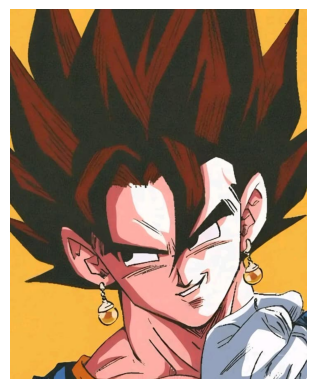

In [9]:
#Leer imagen
img = cv2.imread("img.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#Mostrar imagen
plt.imshow(img_rgb)
plt.axis('off') # Quita las medidas
plt.show()

La razón por la que Jupyter no muestra tu imagen con cv2 es porque cv2.imshow() está diseñado para ventanas de escritorio y no funciona directamente en los notebooks de Jupyter. Además, cv2 utiliza el orden de color BGR, mientras que las bibliotecas de visualización en Jupyter, como Matplotlib, esperan el formato RGB, lo que puede causar una visualización de colores incorrecta si no se hace la conversión.

    Conversión de espacios de color

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

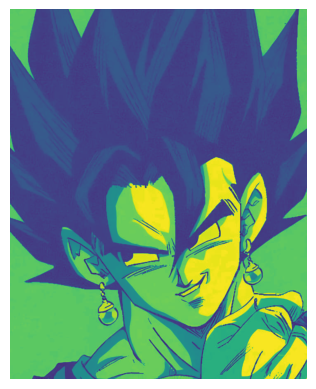

In [31]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray)
plt.axis('off')

    Redimensionamiento y recorte

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

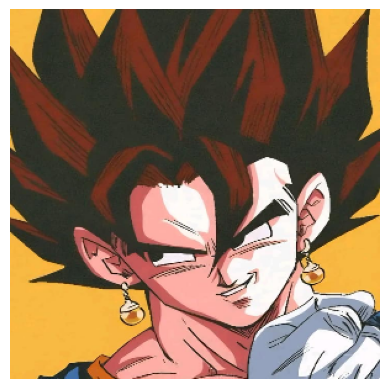

In [33]:
resized = cv2.resize(img_rgb, (300, 300))
plt.imshow(resized)
plt.axis('off')


(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

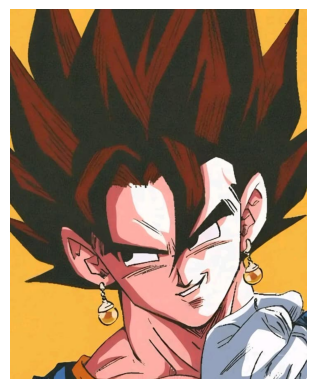

In [39]:
#Slicing de NumPy
crop = img_rgb[50:200, 100:250]
plt.imshow(img_rgb)
plt.axis('off')

    Filtros y suavizados
reducir el ruido o los detalles innecesarios de una imagen.

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

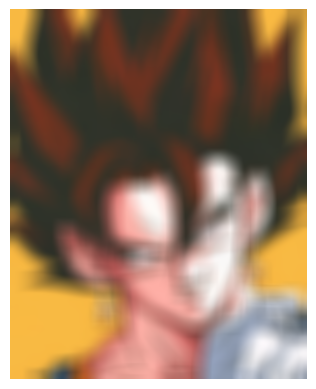

In [75]:
#Filtro Mean Blur
#Promedia los píxeles dentro de una ventana.
blur = cv2.blur(img_rgb, (50,50)) #(blur en x, blur en y)
plt.imshow(blur)
plt.axis("off")

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

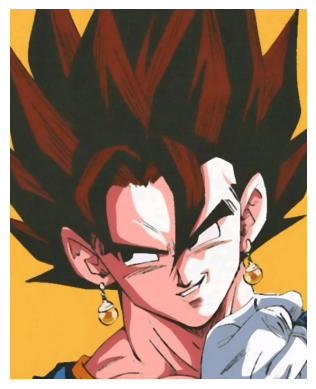

In [ ]:
#Filtro Mediana
#Reemplaza cada píxel por la mediana de su vecindario, util para reducir puntos blancos y negros
median = cv2.medianBlur(img_rgb, 5)
plt.imshow(median)
plt.axis("off")

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

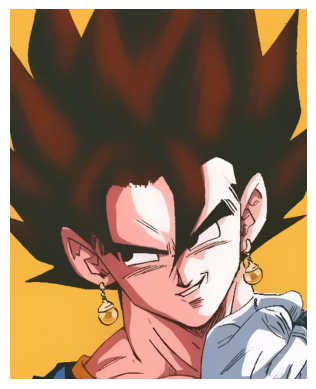

In [83]:
#Filtro Bilateral
#Suaviza sin perder bordes
bilateral = cv2.bilateralFilter(img_rgb, 70, 75, 75)
plt.imshow(bilateral)
plt.axis("off")

    Detección de bordes
Identificar los contornos entre regiones

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

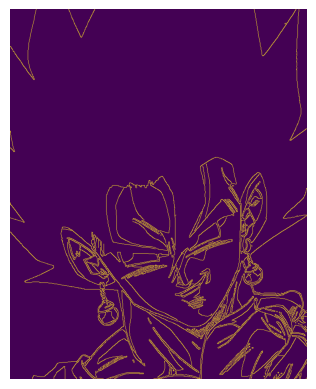

In [87]:
#Canny Edge Detector
edges = cv2.Canny(gray, 100, 200) #Los valores 100 y 200 son umbrales que determinan la sensibilidad.
plt.imshow(edges)
plt.axis("off")

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

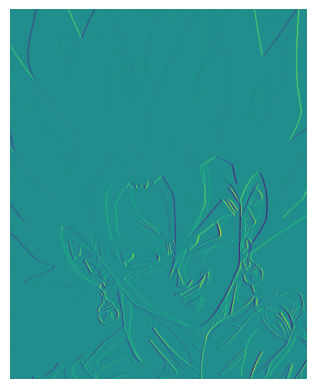

In [99]:
#Sobel/Laplacian
#Derivadas de la imagen para medir cambios de intensidad
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
laplacian = cv2.Laplacian(gray,cv2.CV_64F)

plt.imshow(sobelx)
plt.axis("off")

    Umbralización (thresholding)
Convertir una imagen a blanco y negro según un umbral. Util para detectar texto o números en imágenes escaneadas.

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

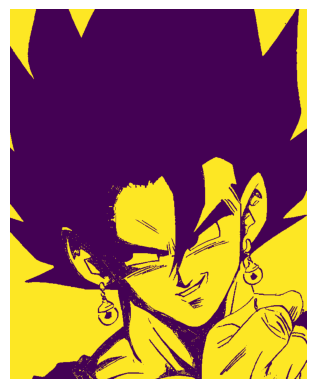

In [105]:
#Umbral fijo
#Todo valor mayor a 127 → 255 (blanco), menor → 0 (negro).
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh)
plt.axis("off")

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

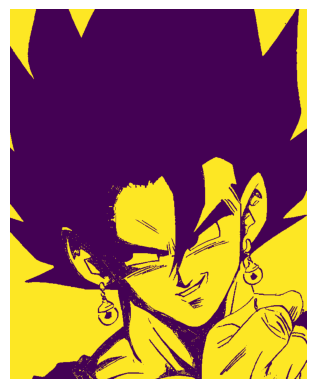

In [106]:
#Umbral adaptativo
#Para imágenes con iluminación irregular.
adaptive = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 11, 2
)
plt.imshow(thresh)
plt.axis("off")

    Detección de Contornos
Encontrar los bordes de los objetos después del thresholding.

(np.float64(-0.5), np.float64(719.5), np.float64(896.5), np.float64(-0.5))

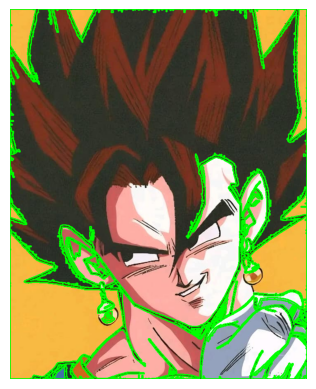

In [114]:
contours, hierarchy = cv2.findContours(adaptive, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# RETR_EXTERNAL: detecta solo los contornos externos.
# CHAIN_APPROX_SIMPLE: reduce los puntos del contorno.

dete_cont = cv2.drawContours(img_rgb, contours, -1, (0,255,0), 2)
plt.imshow(dete_cont)
plt.axis("off")
